In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/dirty_retail_sales.csv')

print("--- Initial Data Info ---")
df.info()
print("\n--- First 5 Rows ---")
print(df.head())

--- Initial Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB

--- First 5 Rows ---
  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22 

In [3]:
df.columns = df.columns.str.strip().str.lower()

print("--- Standardized Column Names ---")
print(df.columns)

--- Standardized Column Names ---
Index(['transaction id', 'customer id', 'category', 'item', 'price per unit',
       'quantity', 'total spent', 'payment method', 'location',
       'transaction date', 'discount applied'],
      dtype='str')


In [4]:
print(df.columns)

Index(['transaction id', 'customer id', 'category', 'item', 'price per unit',
       'quantity', 'total spent', 'payment method', 'location',
       'transaction date', 'discount applied'],
      dtype='str')


In [5]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

print(df.columns)

Index(['transaction_id', 'customer_id', 'category', 'item', 'price_per_unit',
       'quantity', 'total_spent', 'payment_method', 'location',
       'transaction_date', 'discount_applied'],
      dtype='str')


In [6]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  str           
 1   customer_id       12575 non-null  str           
 2   category          12575 non-null  str           
 3   item              11362 non-null  str           
 4   price_per_unit    11966 non-null  float64       
 5   quantity          11971 non-null  float64       
 6   total_spent       11971 non-null  float64       
 7   payment_method    12575 non-null  str           
 8   location          12575 non-null  str           
 9   transaction_date  12575 non-null  datetime64[us]
 10  discount_applied  8376 non-null   object        
dtypes: datetime64[us](1), float64(3), object(1), str(6)
memory usage: 1.1+ MB


In [7]:
df.dropna(subset=['customer_id'], inplace=True)

df['customer_id'] = df['customer_id'].astype(str)

df.dropna(subset=['transaction_date'], inplace=True)

print("--- Missing Values After Handling ---")
print(df.isnull().sum())

--- Missing Values After Handling ---
transaction_id         0
customer_id            0
category               0
item                1213
price_per_unit       609
quantity             604
total_spent          604
payment_method         0
location               0
transaction_date       0
discount_applied    4199
dtype: int64


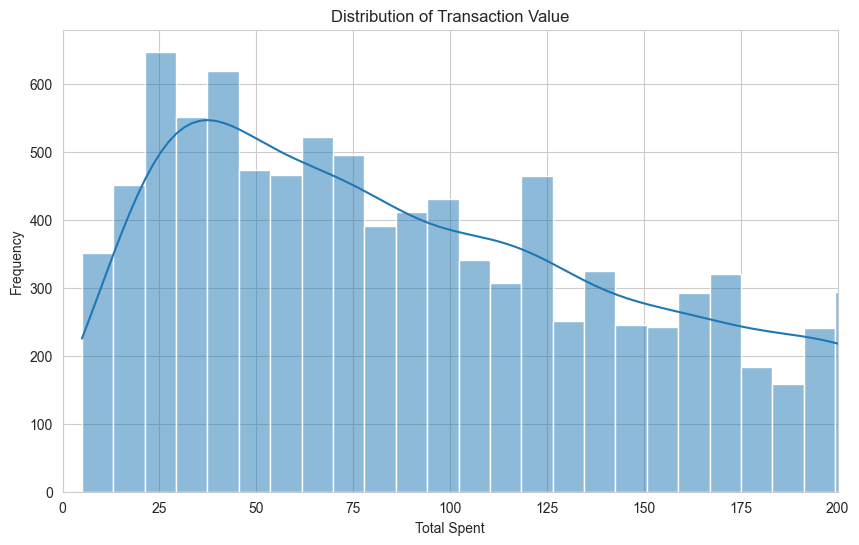

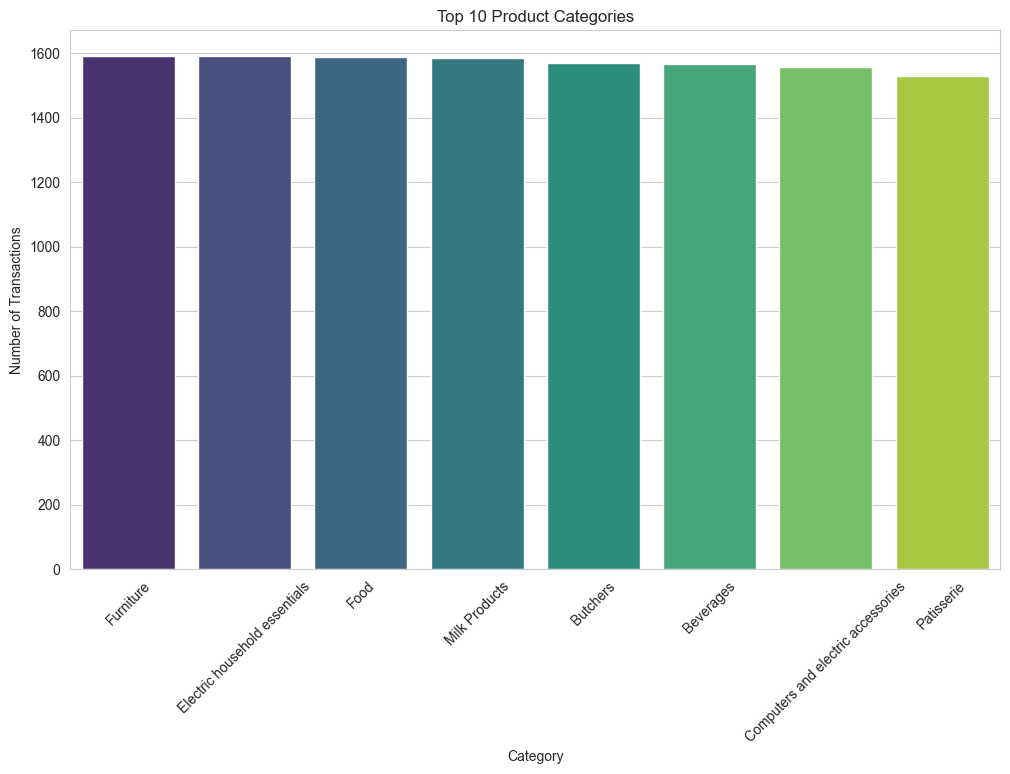

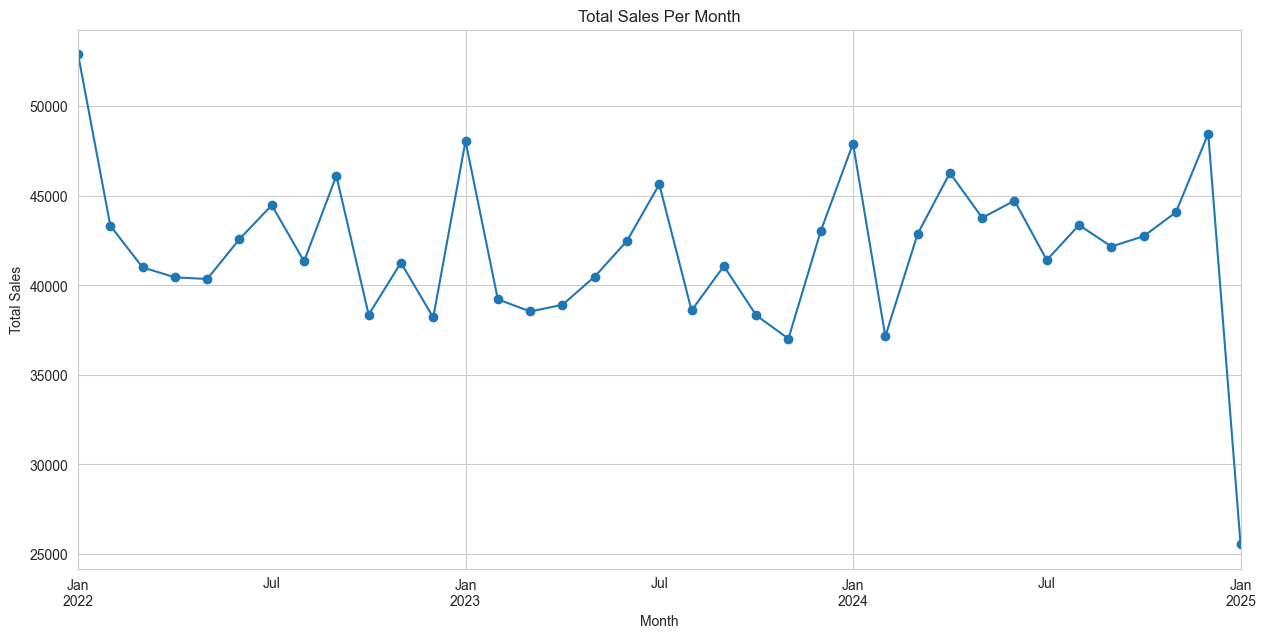

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df['total_spent'], bins=50, kde=True)
plt.title('Distribution of Transaction Value')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.show()

plt.figure(figsize=(12, 7))
top_categories = df['category'].value_counts().head(10)
sns.barplot(x=top_categories.index, y=top_categories.values, hue=top_categories.index, legend=False, palette='viridis')
plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

monthly_sales = df.set_index('transaction_date')['total_spent'].resample('ME').sum()
plt.figure(figsize=(15, 7))
monthly_sales.plot(kind='line', marker='o')
plt.title('Total Sales Per Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

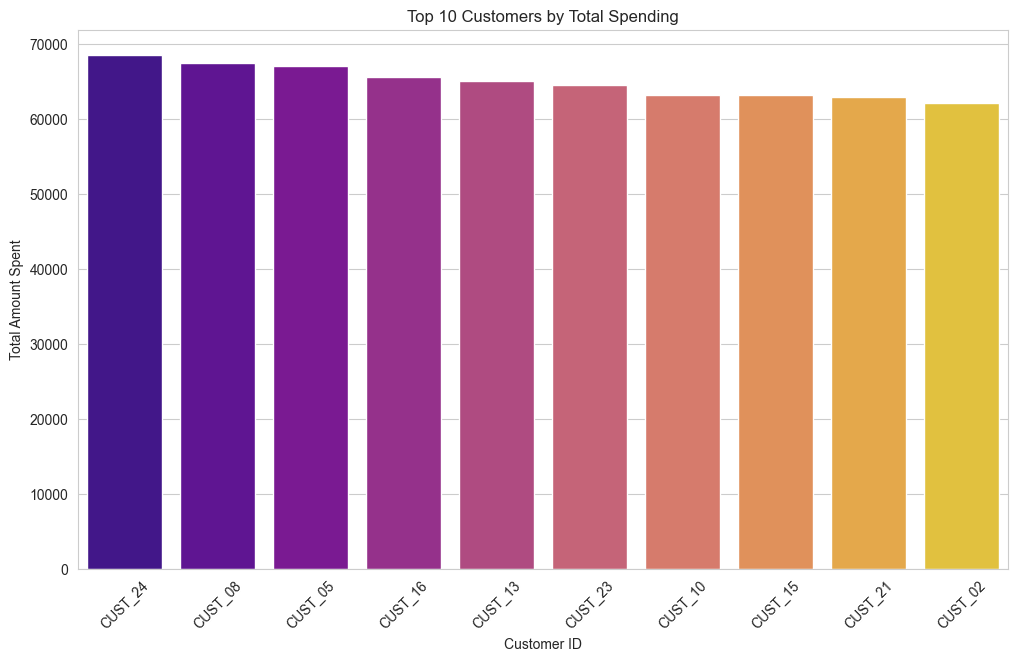

Top 10 Customers:
 customer_id
CUST_24    68452.0
CUST_08    67351.5
CUST_05    66974.5
CUST_16    65570.5
CUST_13    65037.0
CUST_23    64507.0
CUST_10    63155.5
CUST_15    63117.5
CUST_21    62933.0
CUST_02    62046.5
Name: total_spent, dtype: float64


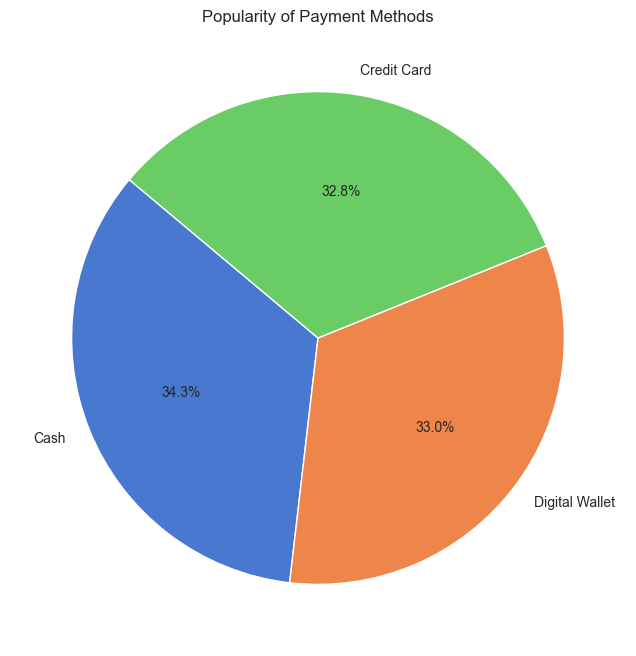

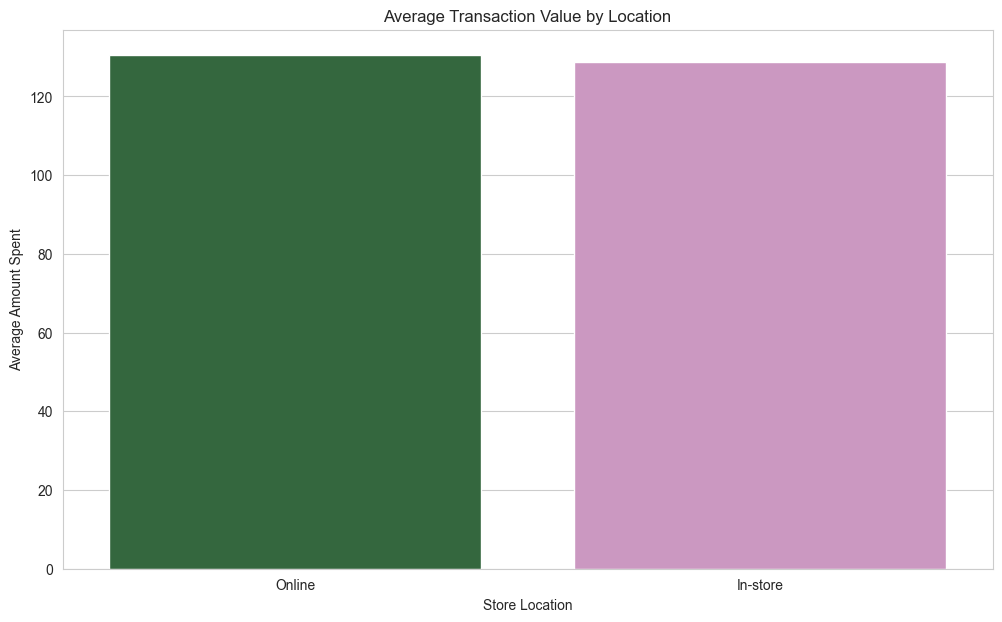

In [10]:
top_customers = df.groupby('customer_id')['total_spent'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_customers.index, y=top_customers.values, hue=top_customers.index, legend=False, palette='plasma', order=top_customers.index)
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45)
plt.show()
print("Top 10 Customers:\n", top_customers)

payment_methods = df['payment_method'].value_counts()
plt.figure(figsize=(10, 8))
plt.pie(payment_methods, labels=payment_methods.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('muted'))
plt.title('Popularity of Payment Methods')
plt.ylabel('')
plt.show()

avg_spent_by_location = df.groupby('location')['total_spent'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_spent_by_location.index, y=avg_spent_by_location.values, hue=avg_spent_by_location.index, legend=False, palette='cubehelix')
plt.title('Average Transaction Value by Location')
plt.xlabel('Store Location')
plt.ylabel('Average Amount Spent')
plt.show()